In [6]:
import pandas as pd
import joblib

# Load train-test data
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Load best model
best_model = joblib.load("../models/best_model.pkl")

print("Everything Loaded Successfully!")

Everything Loaded Successfully!


Feature Importance

In [8]:
print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'previous_contact',
                                                   'multiple_contacts',
                                                   'is_senior', 'stable_job',
                                                   'summer_contact',
                                                   'cluster']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                 

In [11]:
# Extract trained pipeline parts
preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["classifier"]

# Get feature names after One-Hot Encoding
feature_names = preprocessor.get_feature_names_out()

# Create feature importance dataframe
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

# Sort
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
7,num__euribor3m,15.568302
0,num__age,10.471479
8,num__nr.employed,6.725581
1,num__campaign,6.341336
6,num__cons.conf.idx,4.106966
4,num__emp.var.rate,2.906104
2,num__pdays,2.415829
5,num__cons.price.idx,2.301858
48,cat__contact_cellular,2.097380
47,cat__loan_yes,2.084953


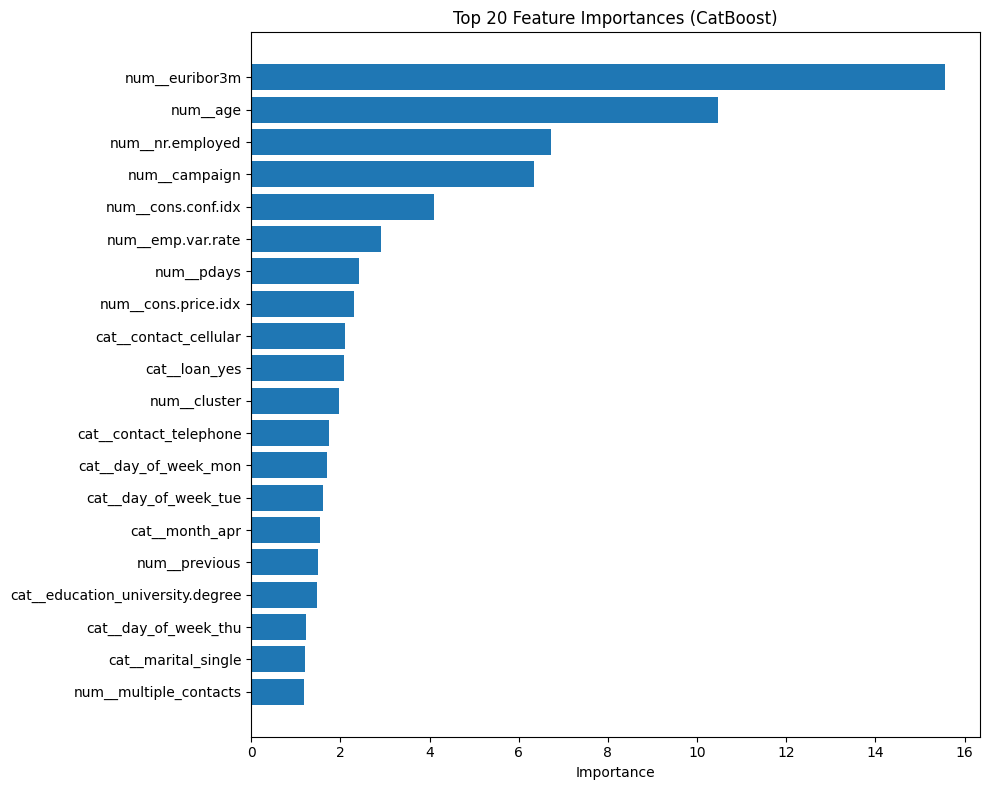

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20],
    importance["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Feature Importances (CatBoost)")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

SHAP Imports

In [13]:
import shap
import matplotlib.pyplot as plt

Extract Pipeline

In [14]:
# Extract preprocessor and classifier
preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["classifier"]

Transform Data

In [15]:
# Transform test data
X_test_transformed = preprocessor.transform(X_test)

print(X_test_transformed.shape)

(8238, 68)


SHAP Explainer

In [16]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

SHAP Summary Plot

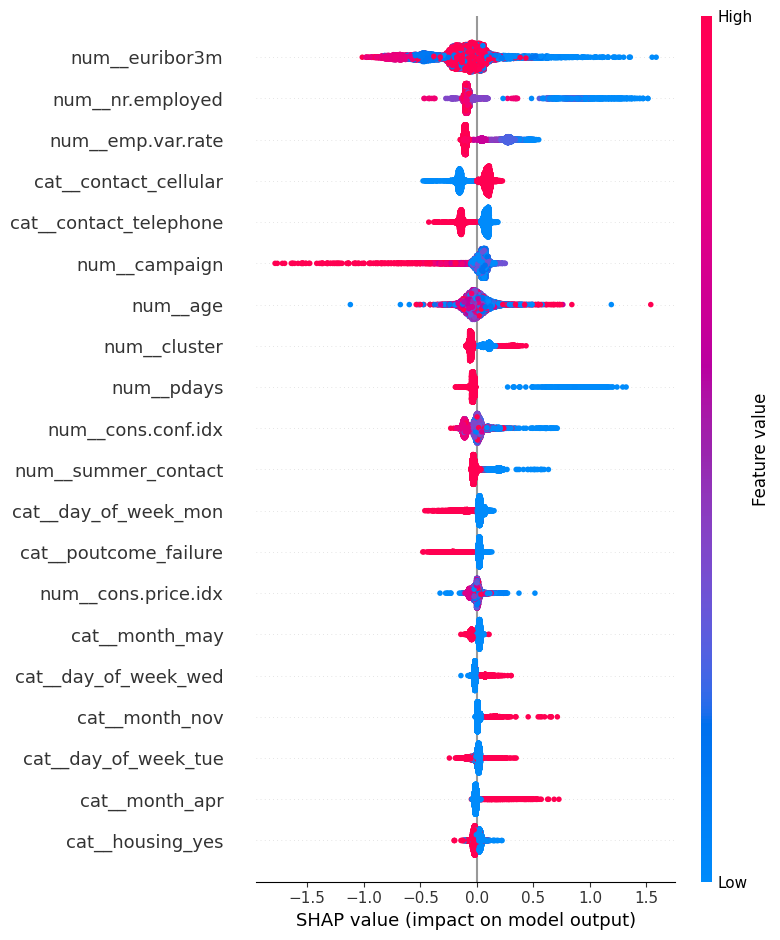

In [17]:
feature_names = preprocessor.get_feature_names_out()

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

SHAP Bar Plot

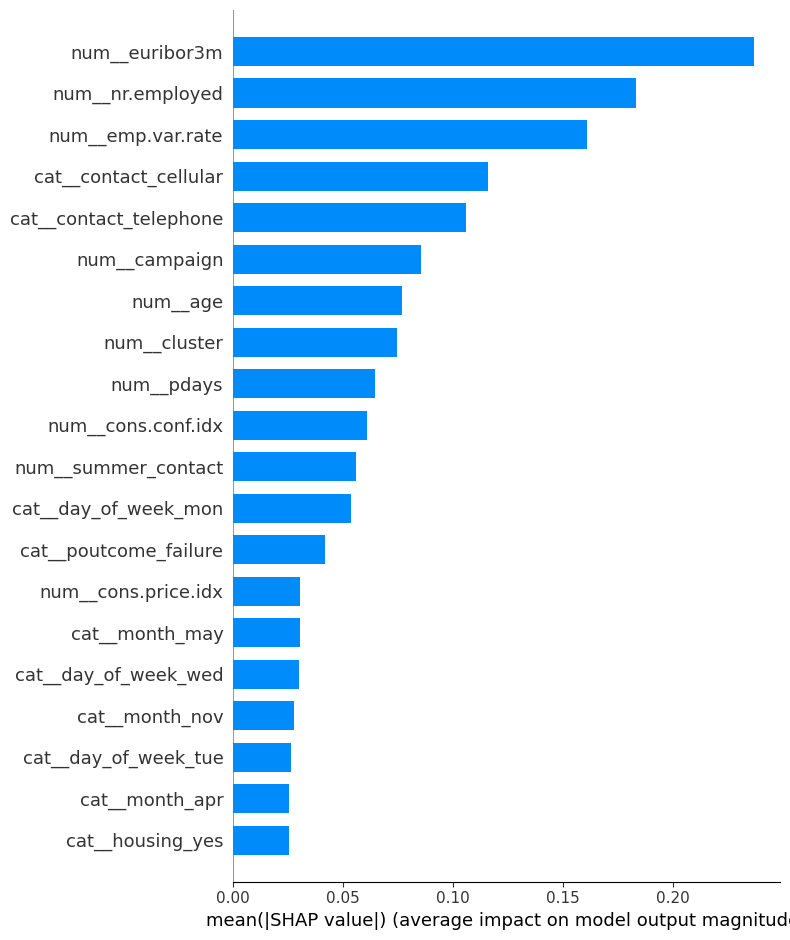

In [18]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)